The first 10 roots of J_{1/2}(x) are: [ 0.        3.141593  6.283185  9.424778 12.566371 15.707963 18.849556
 21.991149 25.132741 28.274334]


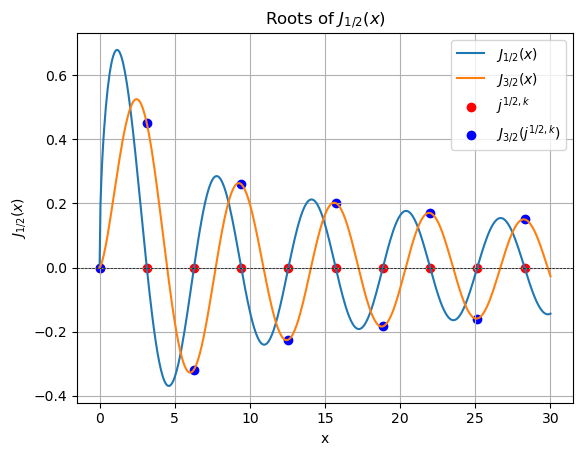

In [1]:
# This code snippet is performing the following tasks:
# This code snippet is performing the following tasks:
import numpy as np
import scipy.special as sp
import scipy.optimize as opt
import matplotlib.pyplot as plt


# Define the Bessel function of the first kind of order 1/2
def bessel_j_half(x):
    return sp.jv(0.5, x)

# Find the roots of the Bessel function
def find_bessel_roots(order, num_roots):
    roots = []
    # Initial guesses for the roots
    x_guesses = np.linspace(1, num_roots*np.pi, num_roots * 10)
    
    for x0 in x_guesses:
        try:
            root = opt.root_scalar(bessel_j_half, bracket=[x0 - 1, x0 + 1], method='brentq')
            if root.converged:
                roots.append(root.root)
        except ValueError:
            continue
    
    # Remove duplicate roots and sort
    roots = np.unique(np.round(roots, decimals=6))
    return roots[:num_roots]

# Number of roots to find
num_roots = 10

# Find the roots
roots = find_bessel_roots(0.5, num_roots)

print(f"The first {num_roots} roots of J_{{1/2}}(x) are: {roots}")

# Plot the Bessel function and its roots
x = np.linspace(0., 30, 500)
y = bessel_j_half(x)
z = sp.jv(1.5,x)

plt.plot(x, y, label=r'$J_{1/2}(x)$')
plt.plot(x, z, label=r'$J_{3/2}(x)$')
plt.scatter(roots, bessel_j_half(roots), color='red', label=r'$j^{1/2,k}$')
plt.scatter(roots, sp.jv(1.5,roots), color='blue', label=r'$J_{3/2}(j^{1/2,k})$')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.xlabel('x')
plt.ylabel(r'$J_{1/2}(x)$')
plt.title(r'Roots of $J_{1/2}(x)$')
plt.legend()
plt.grid(True)
plt.show()

In [2]:
import numpy as np
import scipy.special as sp
import scipy.optimize as opt

class p_absorb(object):
    def __init__(self,**kwargs):
        self.d = kwargs.get("d", 3)
        self.nu = (self.d-2)/2
        self.r_range = kwargs.get("r_range",10 * np.pi)
        self.steps = kwargs.get("resolution",int(self.r_range) * 1000)
        self.find_bessel_roots()

    def bessel_j_half(self,x):
        return sp.jv(self.nu, x)
    def find_bessel_roots(self):
        roots = []
        # Initial guesses for the roots
        x_guesses = np.linspace(1, self.r_range, self.steps)
        dx = self.r_range/self.steps
        for x0 in x_guesses:
            try:
                root = opt.root_scalar(self.bessel_j_half, bracket=[x0 - dx, x0 + dx], method='brentq')
                if root.converged:
                    roots.append(root.root)
            except ValueError:
                continue
        
        # Remove duplicate roots and sort
        roots = np.unique(np.round(roots, decimals=6))
        self.jk = roots[roots>0]
        print("{} roots found!".format(self.jk.shape))


    def __call__(self, cr2):
        ar = np.power(self.jk,self.nu-1)*cr2/((cr2+np.power(self.jk,2))*sp.jv(self.nu+1, self.jk))
        return 1- ar.sum()/(np.power(2,self.nu-1)*sp.gamma(self.nu+1))
    

In [3]:
for i in range(2,6):
    p = p_absorb(d=i,r_range=1000, resolution = 10000)
    print(p(1.))

(318,) roots found!
0.7898484305845199
(318,) roots found!
0.8509191455065018
(318,) roots found!
0.8847263943330526
(317,) roots found!
0.9057603023473944


# Formula (2.7) in Hamana--Matsumoto 2013

In [4]:
p = p_absorb(d=2,r_range=100000, resolution = 1000000)
cr2 = 1.
p(cr2)

(31831,) roots found!


0.7898483909326862

# Solving Poisson with SoV

$\nabla^2 u -u = 0$
$u=1$ on the boundary

$u(r,\theta)=A_0I_0(r)+\sum_{k=1}^\infty I_k(r)(A_k\cos k\theta+B_k\sin k\theta)$

$A_0=1/I_0(1)$

$u(0,\theta)=I_0(0)/I_0(1)=1/I_0(1)$.

In [5]:
sp.iv(0, 0)/sp.iv(0, 1)

0.789848314825112

# Formula (2.1) in Hamana--Matsumoto 2013

In [6]:
1/(np.power(2,p.nu)*sp.gamma(p.nu+1)*sp.iv(p.nu,1))

0.789848314825112

In [14]:
c = 1.
R = 1.
p(c*R*R)

0.7898483909326862

In [44]:
u = np.random.uniform(0, 1, 1)
pr = p(c*R*R)

(0.7898483909326862, array([0.50302415]), 1)

In [53]:
sum = 0
pr = p(c*R*R)
N = 5000
for i in range(N):
    u = np.random.uniform(0, 1, 1)
    sum += (1 if (pr>=u) else 0)
sum/N

0.788

# Without finding roots

In [ ]:
import numpy as np
import scipy.special as sp

class p_absorb_I(object):
    def __init__(self,**kwargs):
        self.d = kwargs.get("d", 3)
        self.nu = (self.d-2)/2

    def __call__(self, cr2):
        return np.power(np.sqrt(cr2),self.nu)/(np.power(2,self.nu)*sp.gamma(self.nu+1)*sp.iv(self.nu,np.sqrt(cr2)))

In [50]:
pi = p_absorb_I(d=2)
pi(1.)

0.789848314825112

In [51]:
for i in range(1,60):
    pi = p_absorb_I(d=i)
    print(pi(20.))

0.022842801402501313
0.05862428322118706
0.10218277610166236
0.14904706111491922
0.19612987190858552
0.24158119578994594
0.28443092878954607
0.3242674300639907
0.36100782353222416
0.39474987482479845
0.42568184481964794
0.45402982211358106
0.48002811844092996
0.5039034379617738
0.5258670904581687
0.5461117982430344
0.5648110506754127
0.5821198074022486
0.5981758569169706
0.6131014364665414
0.6270048956715824
0.6399822893132235
0.6521188443564881
0.6634902801515747
0.6741639794344628
0.6842000175218328
0.6936520617054174
0.7025681545246666
0.7109913946538569
0.7189605283578614
0.7265104633011145
0.7336727151941578
0.7404757964723337
0.7469455549944511
0.7531054696579339
0.7589769088612529
0.7645793569015565
0.7699306126668368
0.775046964355869
0.7799433434235972
0.784633460492457
0.7891299255806673
0.7934443546667181
0.7975874643268891
0.8015691559418922
0.8053985907636826
0.8090842569582297
0.8126340295905552
0.8160552243901587
0.8193546460253385
0.8225386315205776
0.8256130893702888
0